<a href="https://colab.research.google.com/github/Dinithiii04/AgriLak/blob/yield_model_improvements/notebooks/NEW_yield_pred_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paddy Yield Forecasting - Data Pre-processing & Model Implementation




## Preprocessing Yield Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load the dataset
file_path = '/content/drive/MyDrive/Datasets/RAW_yield_data.csv'

maha_yield = pd.read_csv(file_path)

In [4]:
# Add a 'Cultivation_Season' column that matches the format of the weather data
maha_yield['Cultivation_Season'] = (maha_yield['Year'] - 1).astype(str) + '-' + maha_yield['Year'].astype(str)

maha_yield.to_csv('maha_yield.csv', index=False)

# Display the first few rows to verify
display(maha_yield.head(10))


,Year,District,Maha_Yield,Cultivation_Season
0,1979,POLONNARUWA,3547,1978-1979
1,1980,POLONNARUWA,3748,1979-1980
2,1981,POLONNARUWA,3737,1980-1981
3,1982,POLONNARUWA,4707,1981-1982
4,1983,POLONNARUWA,5274,1982-1983
5,1984,POLONNARUWA,3785,1983-1984
6,1985,POLONNARUWA,4874,1984-1985
7,1986,POLONNARUWA,4876,1985-1986
8,1987,POLONNARUWA,4912,1986-1987
9,1988,POLONNARUWA,4341,1987-1988


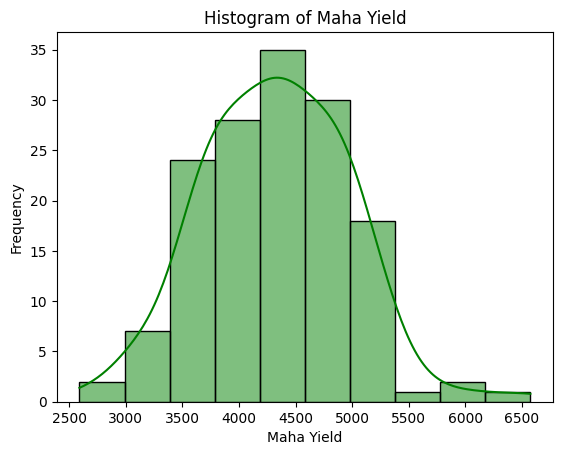

In [5]:
# Histogram of Maha yield
sns.histplot(maha_yield['Maha_Yield'], kde=True, bins=10, color='green')
plt.title('Histogram of Maha Yield')
plt.xlabel('Maha Yield')
plt.ylabel('Frequency')
plt.show()



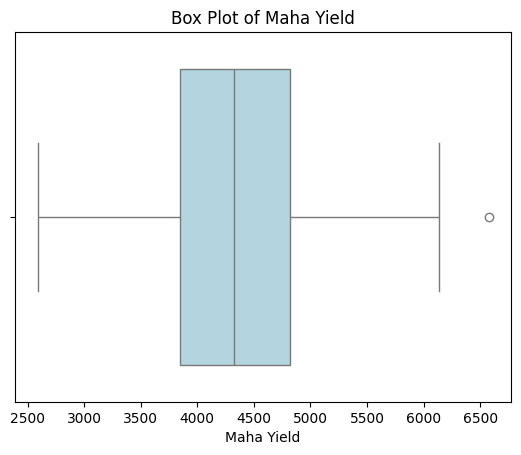

In [6]:
# Box Plot of Maha Yield
sns.boxplot(x=maha_yield['Maha_Yield'], color='lightblue')
plt.title('Box Plot of Maha Yield')
plt.xlabel('Maha Yield')
plt.show()

## Preprocessing Weather Dataset

In [7]:
file_path = '/content/drive/MyDrive/Datasets/RAW_monthly_weather_data.csv'

# Load the dataset
weather_data = pd.read_csv(file_path)
weather_data.head()


,Year,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil
0,1984,1,POLONNARUWA,28.44,22.09,2.69,12.71,89.72,365.56,0.91
1,1984,2,POLONNARUWA,29.21,22.74,2.91,11.65,89.85,326.22,0.97
2,1984,3,POLONNARUWA,31.06,21.32,1.74,19.75,81.56,135.18,0.87
3,1984,4,POLONNARUWA,32.06,22.93,2.21,18.61,84.53,250.59,0.79
4,1984,5,POLONNARUWA,32.02,23.28,2.88,21.00,83.32,39.05,0.73


### Handling Missing Values

In [8]:
# Select only numeric columns
numeric_columns = weather_data.select_dtypes(include=['number'])

# Check for missing values in numeric columns
missing_values_numeric = numeric_columns.isnull().sum()
print("Missing Values:\n", missing_values_numeric, "\n")

# Check for negative values in numeric columns
negative_values_numeric = (numeric_columns < 0).sum()
print("Negative Values:\n", negative_values_numeric)


Missing Values:
 Year     0
Month    0
Tmax     0
Tmin     0
Wind     0
SRAD     0
RH       0
Rain     0
Soil     0
dtype: int64 

Negative Values:
 Year     0
Month    0
Tmax     0
Tmin     0
Wind     0
SRAD     0
RH       0
Rain     0
Soil     0
dtype: int64


### Determine Relevant Months for Maha Season

The Maha season in Sri Lanka spans from **September to March** in the following year, roughly covering **Standard Meteorological Weeks (SMWs) 36 to 13**, which crosses over two calendar years. This aligns with the North-East Monsoon and represents one of the two main paddy cultivation seasons in Sri Lanka, as defined by the *Department of Census and Statistics in Sri Lanka*.

### Filter Data for the Maha Season

In [9]:
# Define Maha season months
maha_months_full = [8, 9, 10, 11, 12, 1, 2]

maha_season_data = weather_data[
    (
        ((weather_data['Month'].isin([8, 9, 10, 11, 12])) & (weather_data['Year'] == 1984)) |
        ((weather_data['Month'].isin([1, 2])) & (weather_data['Year'] == 2015)) |
        ((weather_data['Month'].isin(maha_months_full)) & (weather_data['Year'] > 1984) & (weather_data['Year'] < 2015))
    )
]

# Display the filtered dataset
display(maha_season_data)


,Year,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil
7,1984,8,POLONNARUWA,33.45,22.56,4.58,19.53,77.00,54.60,0.52
8,1984,9,POLONNARUWA,35.05,21.91,3.54,19.81,76.73,301.86,0.54
9,1984,10,POLONNARUWA,30.90,20.35,3.24,18.66,83.97,113.58,0.65
10,1984,11,POLONNARUWA,30.11,21.86,2.10,16.61,86.68,303.79,0.70
11,1984,12,POLONNARUWA,29.84,19.93,2.67,15.23,85.72,95.29,0.75
...,...,...,...,...,...,...,...,...,...,...
1521,2014,10,HAMBANTOTA,29.01,25.51,3.96,19.25,83.48,525.11,0.76
1522,2014,11,HAMBANTOTA,29.84,25.01,3.97,15.19,84.22,375.87,0.88
1523,2014,12,HAMBANTOTA,28.72,24.89,3.36,13.51,86.73,707.49,0.95
1524,2015,1,HAMBANTOTA,28.63,23.60,4.17,19.91,82.36,40.71,0.89


In [10]:
maha_season_data = maha_season_data.copy()

In [11]:
# Assign Cultivation Season based on months
maha_season_data['Cultivation_Season'] = np.where(
    maha_season_data['Month'] >= 8,
    maha_season_data['Year'].astype(str) + '-' + (maha_season_data['Year'] + 1).astype(str),
    (maha_season_data['Year'] - 1).astype(str) + '-' + maha_season_data['Year'].astype(str)
)

cols = list(maha_season_data.columns)
cols.insert(1, cols.pop(cols.index('Cultivation_Season')))

# Apply new column order
maha_season_data = maha_season_data[cols]

# Display modified dataframe
display(maha_season_data.head(20))


,Year,Cultivation_Season,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil
7,1984,1984-1985,8,POLONNARUWA,33.45,22.56,4.58,19.53,77.00,54.60,0.52
8,1984,1984-1985,9,POLONNARUWA,35.05,21.91,3.54,19.81,76.73,301.86,0.54
9,1984,1984-1985,10,POLONNARUWA,30.90,20.35,3.24,18.66,83.97,113.58,0.65
10,1984,1984-1985,11,POLONNARUWA,30.11,21.86,2.10,16.61,86.68,303.79,0.70
11,1984,1984-1985,12,POLONNARUWA,29.84,19.93,2.67,15.23,85.72,95.29,0.75
12,1985,1984-1985,1,POLONNARUWA,28.92,21.73,2.61,16.55,86.11,117.61,0.72
13,1985,1984-1985,2,POLONNARUWA,30.31,20.39,2.21,17.13,83.26,98.51,0.65
19,1985,1985-1986,8,POLONNARUWA,34.70,23.28,5.09,19.11,69.59,67.72,0.43
20,1985,1985-1986,9,POLONNARUWA,35.93,23.15,3.94,19.80,71.95,105.31,0.45
21,1985,1985-1986,10,POLONNARUWA,33.12,22.34,2.99,18.62,79.02,145.34,0.53


## Merge Weather and Yield Data

In [12]:
maha_season_data = maha_season_data.drop(columns=['Year'])

# Merge the weather data with the yield data
merged_data = maha_season_data.merge(
    maha_yield,
    on=['District', 'Cultivation_Season'],
    how='left'
)

display(merged_data.head(20))


,Cultivation_Season,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil,Year,Maha_Yield
0,1984-1985,8,POLONNARUWA,33.45,22.56,4.58,19.53,77.00,54.60,0.52,1985,4874
1,1984-1985,9,POLONNARUWA,35.05,21.91,3.54,19.81,76.73,301.86,0.54,1985,4874
2,1984-1985,10,POLONNARUWA,30.90,20.35,3.24,18.66,83.97,113.58,0.65,1985,4874
3,1984-1985,11,POLONNARUWA,30.11,21.86,2.10,16.61,86.68,303.79,0.70,1985,4874
4,1984-1985,12,POLONNARUWA,29.84,19.93,2.67,15.23,85.72,95.29,0.75,1985,4874
5,1984-1985,1,POLONNARUWA,28.92,21.73,2.61,16.55,86.11,117.61,0.72,1985,4874
6,1984-1985,2,POLONNARUWA,30.31,20.39,2.21,17.13,83.26,98.51,0.65,1985,4874
7,1985-1986,8,POLONNARUWA,34.70,23.28,5.09,19.11,69.59,67.72,0.43,1986,4876
8,1985-1986,9,POLONNARUWA,35.93,23.15,3.94,19.80,71.95,105.31,0.45,1986,4876
9,1985-1986,10,POLONNARUWA,33.12,22.34,2.99,18.62,79.02,145.34,0.53,1986,4876


In [13]:
# Weather variables and month names in seasonal order
weather_variables = ['Tmax', 'Tmin', 'Wind', 'SRAD', 'RH', 'Rain', 'Soil']
month_names = ['Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb']
month_name_map = dict(zip([8, 9, 10, 11, 12, 1, 2], month_names))


In [14]:
# Create a copy of the data
pivot_data = merged_data.copy()

# Extract the yield year from the Cultivation_Season
pivot_data['Year'] = pivot_data['Cultivation_Season'].apply(lambda x: int(x.split('-')[1]))

# Pivot to wide format with month-specific columns
pivot_data = pivot_data.pivot_table(
    index=['Cultivation_Season', 'District', 'Year', 'Maha_Yield'],
    columns='Month',
    values=weather_variables,
    aggfunc='first'
)

# Flatten MultiIndex columns
pivot_data.columns = [f"{month_name_map[month]}_{var}" for var, month in pivot_data.columns]

# Reset index to keep 'Year' as a regular column
pivot_data = pivot_data.reset_index()

# Ensure the correct seasonal column order
ordered_columns = (
    ['Cultivation_Season', 'District', 'Year', 'Maha_Yield'] +
    [f"{month}_{var}" for month in month_names for var in weather_variables]
)

# Reorder the DataFrame columns
pivot_data = pivot_data[ordered_columns]

# Display the restructured DataFrame
display(pivot_data.head(20))


,Cultivation_Season,District,Year,Maha_Yield,Aug_Tmax,Aug_Tmin,Aug_Wind,Aug_SRAD,Aug_RH,Aug_Rain,...,Jan_RH,Jan_Rain,Jan_Soil,Feb_Tmax,Feb_Tmin,Feb_Wind,Feb_SRAD,Feb_RH,Feb_Rain,Feb_Soil
0,1984-1985,AMPARA,1985,3827,32.13,25.16,3.21,19.53,72.28,53.23,...,82.96,83.80,0.74,28.88,23.81,3.09,17.13,80.58,105.64,0.67
1,1984-1985,ANURADHAPURA,1985,3972,34.34,22.63,3.97,21.48,79.94,32.92,...,87.42,124.90,0.79,30.34,17.41,1.87,18.27,84.91,101.05,0.73
2,1984-1985,HAMBANTOTA,1985,4328,29.04,24.43,6.09,19.79,84.41,45.28,...,83.32,49.24,0.65,29.77,23.10,3.48,17.81,80.12,140.05,0.62
3,1984-1985,POLONNARUWA,1985,4874,33.45,22.56,4.58,19.53,77.00,54.60,...,86.11,117.61,0.72,30.31,20.39,2.21,17.13,83.26,98.51,0.65
4,1985-1986,AMPARA,1986,3287,33.29,25.18,3.24,19.11,67.45,52.46,...,84.76,347.53,0.83,28.45,23.09,3.33,18.44,78.93,83.19,0.76
5,1985-1986,ANURADHAPURA,1986,4567,34.58,23.11,4.54,18.83,71.21,68.23,...,88.61,201.04,0.79,30.24,17.51,1.98,19.20,83.28,43.59,0.67
6,1985-1986,HAMBANTOTA,1986,4194,29.42,25.35,6.34,18.61,79.78,26.03,...,84.71,330.72,0.74,28.69,23.45,3.76,20.65,79.53,68.26,0.65
7,1985-1986,POLONNARUWA,1986,4876,34.70,23.28,5.09,19.11,69.59,67.72,...,87.44,286.10,0.73,29.91,20.26,2.36,18.44,82.18,71.96,0.63
8,1986-1987,AMPARA,1987,3606,33.87,24.67,3.31,20.23,69.17,99.33,...,82.78,136.18,0.66,29.21,23.05,3.68,19.55,77.71,82.64,0.63
9,1986-1987,ANURADHAPURA,1987,3867,37.27,22.68,5.11,19.95,69.40,33.25,...,76.97,68.65,0.54,36.36,17.37,2.63,21.18,68.24,15.47,0.50
